# Development to Autonomous Robot


In [1]:
from tp_rob201.control import potential_field_control
import numpy as np


# STEP 01 : Reactive Control

# Step 02: Potential Field Control 


Potential field control is simple and intuitive, but it is not guaranteed to find a globally optimal path. Because the total force is defined as the sum of attractive (to the goal) and repulsive (from obstacles) components, the resulting potential landscape can contain **local minima**. In these configurations, the net force becomes (near) zero at a point that is not the goal, causing the robot to stop or oscillate without making progress. This issue is especially common in environments with narrow passages, symmetric obstacle layouts, or concave regions, where repulsive forces can balance the attraction to the target and prevent convergence to the optimal solution.

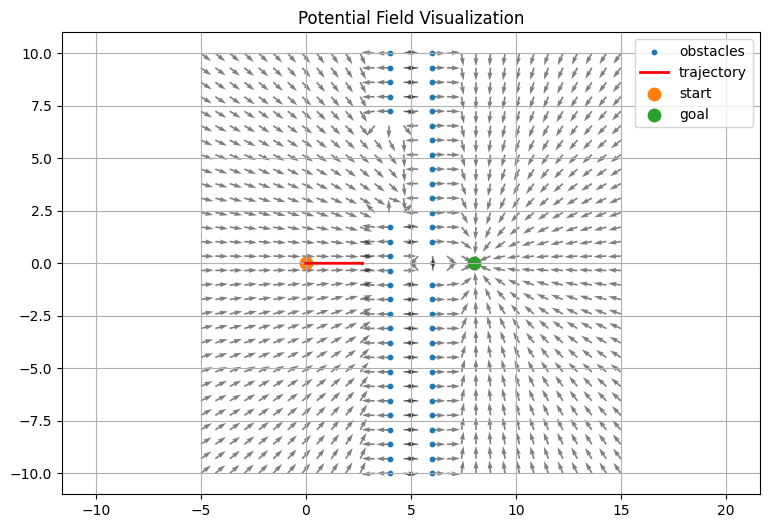

In [9]:
import numpy as np
import matplotlib.pyplot as plt


goal = np.array([8.0, 0.0])

# Walls
obstacles = np.array(
    [
        [4.0, y]
        for y in np.linspace(-10, 10, 30)
        if (y < 2.0) or (y > 7.0)  
    ]
    + [
        [6.0, y]
        for y in np.linspace(-10, 10, 30)
        if abs(y) > 1.0
    ],
    dtype=float,
)

k_att = 1.0
k_rep = 500
dist_inf = 1.5

def compute_force(p):
    F_att = k_att * (goal - p)
    F_rep = np.zeros(2)

    for obs in obstacles:
        diff = p - obs
        d = np.linalg.norm(diff)

        if 0.01 < d < dist_inf:
            rep = k_rep * (1/d - 1/dist_inf)**2
            F_rep += rep * (diff / d)

    return F_att + F_rep


pos = np.array([0.0, 0.0])
theta = 0.0  # orientação do robô
traj = [pos.copy()]

dt = 0.1

for _ in range(200):

    F = compute_force(pos)
    desired_angle = np.arctan2(F[1], F[0])

    # erro angular
    angle_error = desired_angle - theta
    angle_error = np.arctan2(np.sin(angle_error), np.cos(angle_error))

    # controle simples
    rot = np.clip(angle_error, -0.5, 0.5)
    forward = 0.5 * max(0, 1 - abs(angle_error))  # só anda se alinhado

    # atualizar estado
    theta += rot * dt
    pos += np.array([np.cos(theta), np.sin(theta)]) * forward * dt

    traj.append(pos.copy())

    if np.linalg.norm(goal - pos) < 0.2:
        break

traj = np.array(traj)

# =========================
# VETORES DO CAMPO
# =========================
X, Y = np.meshgrid(np.linspace(-5, 15, 30), np.linspace(-10, 10, 30))
U = np.zeros_like(X)
V = np.zeros_like(Y)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        F = compute_force(np.array([X[i, j], Y[i, j]]))
        norm = np.linalg.norm(F)
        if norm > 1e-6:
            F = F / norm
        U[i, j], V[i, j] = F

# =========================
# PLOT
# =========================
plt.figure(figsize=(9,6))

plt.quiver(X, Y, U, V, alpha=0.5)

plt.scatter(obstacles[:,0], obstacles[:,1], s=10, label="obstacles")
plt.plot(traj[:,0], traj[:,1], 'r-', linewidth=2, label="trajectory")

plt.scatter(0, 0, s=80, label="start")
plt.scatter(goal[0], goal[1], s=80, label="goal")

plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Potential Field Visualization")
plt.show()

<img src='img/map-cem.png'>

# Improvement - EKF Posing estimation

In this method, we model the system based on EKF estimation, that allows us with more precision estimate the robot pose. 

## Brief intro to EKF, how it Works

The **Extended Kalman Filter (EKF)** estimates a robot’s pose when motion/sensor models are **nonlinear**, keeping a Gaussian belief (mean + covariance). As an algo. he works by repeatidly doing these following steps:

- **Predict:** apply the motion model (controls/odometry) and increase uncertainty.  
- **Linearize:** use **Jacobians** to approximate nonlinear models locally.  
- **Update:** fuse measurements by correcting the estimate using the **innovation** (expected vs. observed), reducing covariance.
